# SAINT — GP2 Tabular SSL Research

**Student:** Zain Qerba (160201)  
**Supervisor:** Dana El Rushaidat  
**University:** Jordan University of Science and Technology  

---

## Purpose
This notebook trains **SAINT (Self-Attention and Intersample Attention Transformer)**
on the Adult Income dataset at 8 data fractions (100%, 50%, 10%, 8%, 6%, 4%, 2%, 1%).  
SAINT uses **built-in self-supervised pretraining** via combined denoising and contrastive
objectives before supervised fine-tuning — making it the SSL deep learning baseline
for Adult Income.  
Results are compared against the XGBoost baseline (notebook 01) to identify the
**crossover point** — the data fraction at which SAINT's SSL pretraining starts
outperforming XGBoost.

## Dataset
| Dataset | Task | Rows | Features |
|---|---|---|---|
| Adult Income | Binary classification (imbalanced ~75/25) | 48,842 | 14 |

## Metrics
- **Adult Income:** ROC-AUC + F1 + PR-AUC *(accuracy is misleading on imbalanced data)*

## Citation
Somepalli, G., et al. (2021). SAINT: Improved Neural Networks for Tabular Data  
via Row Attention and Contrastive Pre-Training. *arXiv:2106.01342*.

In [1]:
# ── Cell 1: Install Dependencies ─────────────────────────────────────────────
!pip install ucimlrepo scikit-learn pandas numpy matplotlib seaborn --quiet

print("All packages installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 4.7 MB/s eta 0:00:00
All packages installed successfully.


In [2]:
# ── Cell 2: Imports ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
print("All imports successful.")

PyTorch version : 2.11.0+cpu
Device          : cpu
All imports successful.


In [3]:
# ── Cell 3: Global Configuration ─────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

FRACTIONS = [1.0, 0.5, 0.1, 0.08, 0.06, 0.04, 0.02, 0.01]

# ── SAINT Hyperparameters ───────
D_MODEL        = 64
N_HEADS        = 8
N_LAYERS       = 3
DROPOUT        = 0.1
BATCH_SIZE     = 256
LR             = 1e-4
PRETRAIN_EPOCHS = 100
FINETUNE_EPOCHS = 100

RESULTS_DIR  = "/content/results"
os.makedirs(RESULTS_DIR, exist_ok=True)
RESULTS_PATH = os.path.join(RESULTS_DIR, "saint_results.csv")
CKPT_DIR     = os.path.join(RESULTS_DIR, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)

print(f"Device          : {device}")
print(f"Results path    : {RESULTS_PATH}")
print(f"Fractions       : {FRACTIONS}")
print(f"d_model         : {D_MODEL}")
print(f"n_heads         : {N_HEADS}")
print(f"n_layers        : {N_LAYERS}")
print(f"Pretrain epochs : {PRETRAIN_EPOCHS}")
print(f"Finetune epochs : {FINETUNE_EPOCHS}")

Device          : cpu
Results path    : /content/results/saint_results.csv
Fractions       : [1.0, 0.5, 0.1, 0.08, 0.06, 0.04, 0.02, 0.01]
d_model         : 64
n_heads         : 8
n_layers        : 3
Pretrain epochs : 100
Finetune epochs : 100


In [4]:
# ── Cell 4: Helper Functions ──────────────────────────────────────────────────
def save_result(row: dict):
    df_row = pd.DataFrame([row])
    file_exists = os.path.isfile(RESULTS_PATH)
    df_row.to_csv(
        RESULTS_PATH,
        mode='a',
        header=not file_exists,
        index=False
    )
    print(f"  Saved: dataset={row['dataset']} | fraction={row['fraction']}")


def subsample(X, y, fraction):
    if fraction >= 1.0:
        return X, y
    sss = StratifiedShuffleSplit(
        n_splits=1,
        test_size=1 - fraction,
        random_state=RANDOM_STATE
    )
    keep_idx, _ = next(sss.split(X, y))
    return X[keep_idx], y[keep_idx]


def get_completed_fractions():
    """Returns list of fractions already saved — for disconnection recovery."""
    if not os.path.isfile(RESULTS_PATH):
        return []
    done = pd.read_csv(RESULTS_PATH)
    return done['fraction'].tolist()


print("Helper functions ready.")

Helper functions ready.


In [5]:
# ── Cell 5: Load & Preprocess Adult Income ───────────────────────────────────
print("Loading Adult Income dataset...")

adult = fetch_ucirepo(id=2)
X_adult_raw = adult.data.features
y_adult_raw = adult.data.targets

y_adult = y_adult_raw.iloc[:, 0].str.strip().str.rstrip('.')
le_target = LabelEncoder()
y_adult = le_target.fit_transform(y_adult)

X_adult = X_adult_raw.copy()
le_feat = LabelEncoder()
for col in X_adult.columns:
    if X_adult[col].dtype == object:
        X_adult[col] = X_adult[col].fillna('Unknown')
        X_adult[col] = le_feat.fit_transform(X_adult[col])
    else:
        X_adult[col] = X_adult[col].fillna(X_adult[col].median())

X_adult = X_adult.values.astype(np.float32)
y_adult = y_adult.astype(np.int64)

print(f"X shape      : {X_adult.shape}")
print(f"Label classes: {le_target.classes_}")
neg = np.sum(y_adult == 0)
pos = np.sum(y_adult == 1)
print(f"Balance      : {neg} neg | {pos} pos")

Loading Adult Income dataset...
X shape      : (48842, 14)
Label classes: ['<=50K' '>50K']
Balance      : 37155 neg | 11687 pos


In [6]:
# ── Cell 6: Train/Test Split ──────────────────────────────────────────────────
X_adult_train, X_adult_test, y_adult_train, y_adult_test = train_test_split(
    X_adult, y_adult,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_adult
)

scaler = StandardScaler()
X_adult_train = scaler.fit_transform(X_adult_train).astype(np.float32)
X_adult_test  = scaler.transform(X_adult_test).astype(np.float32)

print(f"Train : {X_adult_train.shape[0]:,}  |  Test : {X_adult_test.shape[0]:,}")
print(f"Train balance: {np.sum(y_adult_train==0):,} neg | {np.sum(y_adult_train==1):,} pos")
print("Scaling complete.")

Train : 39,073  |  Test : 9,769
Train balance: 29,724 neg | 9,349 pos
Scaling complete.


In [7]:
# ── Cell 7: PyTorch Dataset ───────────────────────────────────────────────────
class TabularDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long) if y is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return (self.X[idx],)


def get_loader(X, y=None, batch_size=256, shuffle=True):
    ds = TabularDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


print("TabularDataset and get_loader ready.")

TabularDataset and get_loader ready.


In [8]:
# ── Cell 8: SAINT Model Architecture ─────────────────────────────────────────
class FeatureEmbedding(nn.Module):
    def __init__(self, input_dim, d_model):
        super().__init__()
        self.proj = nn.Linear(input_dim, d_model)

    def forward(self, x):
        return self.proj(x)


class SelfAttentionBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm1(x + self.drop(attn_out))
        x = self.norm2(x + self.drop(self.ff(x)))
        return x


class IntersampleAttentionBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        x_t = x.transpose(0, 1)
        attn_out, _ = self.attn(x_t, x_t, x_t)
        x_t = self.norm1(x_t + self.drop(attn_out))
        x_t = self.norm2(x_t + self.drop(self.ff(x_t)))
        return x_t.transpose(0, 1)


class SAINT(nn.Module):
    def __init__(self, input_dim, d_model=64, n_heads=8, n_layers=3,
                 dropout=0.1, num_classes=2):
        super().__init__()
        self.embedding = FeatureEmbedding(input_dim, d_model)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'self_attn'  : SelfAttentionBlock(d_model, n_heads, dropout),
                'inter_attn' : IntersampleAttentionBlock(d_model, n_heads, dropout),
            })
            for _ in range(n_layers)
        ])
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )
        self.denoising_head    = nn.Linear(d_model, input_dim)
        self.contrastive_head  = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model // 2)
        )

    def encode(self, x):
        h = self.embedding(x).unsqueeze(1)
        for layer in self.layers:
            h = layer['self_attn'](h)
            h = layer['inter_attn'](h)
        return h.squeeze(1)

    def forward(self, x):
        return self.classifier(self.encode(x))


# Sanity check
_m = SAINT(input_dim=14, d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS).to(device)
_x = torch.randn(32, 14).to(device)
print(f"Output shape     : {_m(_x).shape}")
print(f"Parameter count  : {sum(p.numel() for p in _m.parameters()):,}")
del _m, _x
print("SAINT architecture ready.")

Output shape     : torch.Size([32, 2])
Parameter count  : 310,288
SAINT architecture ready.


In [9]:
# ── Cell 9: SSL Pretraining Functions ────────────────────────────────────────
# Two SSL objectives run together during pretraining:
#
# 1. DENOISING — corrupt input features by randomly zeroing some out,
#    ask the model to reconstruct the original. Forces the encoder to
#    learn meaningful feature relationships.
#
# 2. CONTRASTIVE — create two augmented views of the same row by adding
#    small gaussian noise, encode both, and pull their embeddings together
#    while pushing embeddings of different rows apart (NT-Xent loss).

def corrupt_features(x, corruption_rate=0.3):
    """Randomly zero out a fraction of features in each row."""
    mask = torch.bernoulli(
        torch.full(x.shape, 1 - corruption_rate, device=x.device)
    )
    return x * mask


def nt_xent_loss(z1, z2, temperature=0.5):
    """
    NT-Xent contrastive loss (SimCLR-style).
    z1, z2: (batch, proj_dim) — two views of the same samples.
    Pulls z1[i] and z2[i] together, pushes apart all other pairs.
    """
    batch_size = z1.shape[0]

    # Normalize to unit sphere
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)

    # Concatenate both views: (2*batch, proj_dim)
    z  = torch.cat([z1, z2], dim=0)

    # Similarity matrix: (2*batch, 2*batch)
    sim = torch.mm(z, z.T) / temperature

    # Mask out self-similarity on the diagonal
    mask = torch.eye(2 * batch_size, device=z.device).bool()
    sim.masked_fill_(mask, -9e15)

    # Positive pairs: (i, i+batch) and (i+batch, i)
    labels = torch.cat([
        torch.arange(batch_size, 2 * batch_size, device=z.device),
        torch.arange(0, batch_size, device=z.device)
    ])

    return F.cross_entropy(sim, labels)


def pretrain_epoch(model, loader, optimizer, corruption_rate=0.3):
    """One pretraining epoch — combines denoising + contrastive loss."""
    model.train()
    total_loss = 0.0

    for batch in loader:
        x = batch[0].to(device)

        # ── Denoising ─────────────────────────────────────────────────────────
        x_corrupted = corrupt_features(x, corruption_rate)
        h_corrupted = model.encode(x_corrupted)
        x_recon     = model.denoising_head(h_corrupted)
        loss_denoise = F.mse_loss(x_recon, x)

        # ── Contrastive ───────────────────────────────────────────────────────

        x_v1 = x + 0.05 * torch.randn_like(x)
        x_v2 = x + 0.05 * torch.randn_like(x)
        z1   = model.contrastive_head(model.encode(x_v1))
        z2   = model.contrastive_head(model.encode(x_v2))
        loss_contrast = nt_xent_loss(z1, z2)

        loss = loss_denoise + loss_contrast

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def pretrain(model, X_unlabeled, epochs=50, lr=1e-3, batch_size=256):
    """
    Pretrain SAINT on unlabeled data using denoising + contrastive objectives.
    X_unlabeled = entire training set (no labels used here).
    """
    loader    = get_loader(X_unlabeled, y=None, batch_size=batch_size)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    print(f"  Pretraining for {epochs} epochs on {len(X_unlabeled):,} samples...")
    for epoch in range(1, epochs + 1):
        loss = pretrain_epoch(model, loader, optimizer)
        scheduler.step()
        if epoch % 10 == 0:
            print(f"    Epoch {epoch:>3}/{epochs} | Loss: {loss:.4f}")

    print("  Pretraining complete.")

print("SSL pretraining functions ready.")

SSL pretraining functions ready.


In [10]:
# ── Cell 10: Fine-tuning & Evaluation ────────────────────────────────────────
def finetune(model, X_tr, y_tr, epochs=100, lr=1e-4, batch_size=256):
    neg = np.sum(y_tr == 0)
    pos = np.sum(y_tr == 1)
    class_weights = torch.tensor([1.0, neg / pos], dtype=torch.float32).to(device)

    loader    = get_loader(X_tr, y_tr, batch_size=batch_size)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.train()
    for epoch in range(1, epochs + 1):
        for x, y in loader:
            x, y   = x.to(device), y.to(device)
            loss   = F.cross_entropy(model(x), y, weight=class_weights)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        scheduler.step()
    return model


@torch.no_grad()
def evaluate(model, X_test, y_test, batch_size=512):
    model.eval()
    loader     = get_loader(X_test, y_test, batch_size=batch_size, shuffle=False)
    all_probs  = []
    all_preds  = []
    all_labels = []

    for x, y in loader:
        x      = x.to(device)
        logits = model(x)
        probs  = F.softmax(logits, dim=1)[:, 1]
        preds  = logits.argmax(dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y.numpy())

    all_probs  = np.concatenate(all_probs)
    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    return (
        roc_auc_score(all_labels, all_probs),
        f1_score(all_labels, all_preds, average='binary'),
        average_precision_score(all_labels, all_probs)
    )


print("Fine-tuning and evaluation functions ready.")

Fine-tuning and evaluation functions ready.


In [11]:
# ── Cell 11: Run SAINT Experiments — All 8 Fractions ─────────────────────────
# Disconnection recovery — skip fractions already saved
completed   = get_completed_fractions()
to_run      = [f for f in FRACTIONS if f not in completed]

if completed:
    print(f"Resuming — already done : {completed}")
    print(f"Remaining               : {to_run}")
else:
    print("Starting fresh.")

print("=" * 60)
print("ADULT INCOME — SAINT across 8 data fractions")
print("=" * 60)

for frac in to_run:
    print(f"\nFraction: {frac*100:.0f}%")

    X_tr, y_tr = subsample(X_adult_train, y_adult_train, frac)
    print(f"  Labeled samples : {len(X_tr):,}")

    # Build model
    model = SAINT(
        input_dim=X_adult_train.shape[1],
        d_model=D_MODEL,
        n_heads=N_HEADS,
        n_layers=N_LAYERS,
        dropout=DROPOUT
    ).to(device)

    # Pretrain on full training set — no labels used
    pretrain(model, X_adult_train,
             epochs=PRETRAIN_EPOCHS, lr=LR, batch_size=BATCH_SIZE)

    # Fine-tune on labeled fraction only
    finetune(model, X_tr, y_tr,
             epochs=FINETUNE_EPOCHS, lr=LR, batch_size=BATCH_SIZE)

    # Evaluate on fixed test set
    roc_auc, f1, pr_auc = evaluate(model, X_adult_test, y_adult_test)
    print(f"  TEST → ROC-AUC: {roc_auc:.4f}  |  F1: {f1:.4f}  |  PR-AUC: {pr_auc:.4f}")

    # Save checkpoint
    ckpt_path = os.path.join(CKPT_DIR, f"saint_frac{frac}.pt")
    torch.save(model.state_dict(), ckpt_path)

    # Save result
    save_result({
        'dataset'           : 'adult_income',
        'model'             : 'saint',
        'fraction'          : frac,
        'n_train_samples'   : len(X_tr),
        'accuracy'          : None,
        'macro_f1'          : None,
        'roc_auc'           : round(roc_auc, 4),
        'pr_auc'            : round(pr_auc, 4),
        'f1'                : round(f1, 4),
        'rmse'              : None,
        'mae'               : None,
        'r2'                : None,
        'best_optuna_params': f'd_model={D_MODEL},n_heads={N_HEADS},n_layers={N_LAYERS},dropout={DROPOUT},lr={LR}'
    })

print("\nSAINT Adult Income experiments complete.")

Starting fresh.
ADULT INCOME — SAINT across 8 data fractions

Fraction: 100%
  Labeled samples : 39,073
  Pretraining for 100 epochs on 39,073 samples...
    Epoch  10/100 | Loss: 4.7046
    Epoch  20/100 | Loss: 4.6461
    Epoch  30/100 | Loss: 4.6279
    Epoch  40/100 | Loss: 4.6102
    Epoch  50/100 | Loss: 4.6070
    Epoch  60/100 | Loss: 4.6033
    Epoch  70/100 | Loss: 4.5999
    Epoch  80/100 | Loss: 4.5924
    Epoch  90/100 | Loss: 4.5951
    Epoch 100/100 | Loss: 4.5995
  Pretraining complete.
  TEST → ROC-AUC: 0.9091  |  F1: 0.6783  |  PR-AUC: 0.7795
  Saved: dataset=adult_income | fraction=1.0

Fraction: 50%
  Labeled samples : 19,536
  Pretraining for 100 epochs on 39,073 samples...
    Epoch  10/100 | Loss: 4.7029
    Epoch  20/100 | Loss: 4.6470
    Epoch  30/100 | Loss: 4.6248
    Epoch  40/100 | Loss: 4.6132
    Epoch  50/100 | Loss: 4.6024
    Epoch  60/100 | Loss: 4.6024
    Epoch  70/100 | Loss: 4.5978
    Epoch  80/100 | Loss: 4.5918
    Epoch  90/100 | Loss: 4.5914

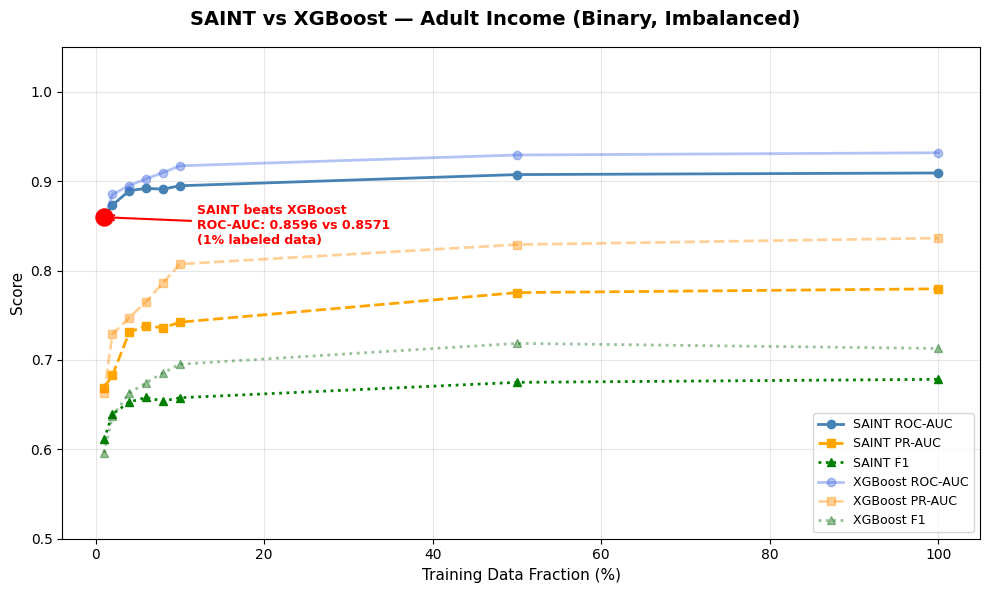

Plot saved.

SAINT vs XGBoost — Adult Income Results
  Fraction |  Samples | XGB ROC-AUC | ST ROC-AUC |     Diff |   Winner
----------------------------------------------------------------------
        1% |      390 |      0.8571 |     0.8596 |  +0.0025 |    SAINT
        2% |      781 |      0.8851 |     0.8731 |  -0.0120 |  XGBoost
        4% |    1,562 |      0.8950 |     0.8893 |  -0.0057 |  XGBoost
        6% |    2,344 |      0.9025 |     0.8919 |  -0.0106 |  XGBoost
        8% |    3,125 |      0.9095 |     0.8910 |  -0.0185 |  XGBoost
       10% |    3,907 |      0.9171 |     0.8948 |  -0.0223 |  XGBoost
       50% |   19,536 |      0.9292 |     0.9073 |  -0.0219 |  XGBoost
      100% |   39,073 |      0.9317 |     0.9091 |  -0.0226 |  XGBoost


In [16]:
# ── Cell 12: SAINT Results Visualization ─────────────────────────────────────
saint_results = pd.read_csv(RESULTS_PATH)
XGB_PATH      = "/content/xgboost_results.csv"
xgb_results   = pd.read_csv(XGB_PATH)

saint_adult = saint_results[saint_results['dataset'] == 'adult_income'].sort_values('fraction')
xgb_adult   = xgb_results[xgb_results['dataset'] == 'adult_income'].sort_values('fraction')

fractions_pct = saint_adult['fraction'] * 100

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('SAINT vs XGBoost — Adult Income (Binary, Imbalanced)',
             fontsize=14, fontweight='bold')

# ── SAINT metrics ─────────────────────────────────────────────────────────────
ax.plot(fractions_pct, saint_adult['roc_auc'],
        'o-', color='steelblue', label='SAINT ROC-AUC', linewidth=2)
ax.plot(fractions_pct, saint_adult['pr_auc'],
        's--', color='orange', label='SAINT PR-AUC', linewidth=2)
ax.plot(fractions_pct, saint_adult['f1'],
        '^:', color='green', label='SAINT F1', linewidth=2)

# ── XGBoost metrics ───────────────────────────────────────────────────────────
ax.plot(fractions_pct, xgb_adult['roc_auc'],
        'o-', color='royalblue', label='XGBoost ROC-AUC',
        linewidth=2, alpha=0.4)
ax.plot(fractions_pct, xgb_adult['pr_auc'],
        's--', color='darkorange', label='XGBoost PR-AUC',
        linewidth=2, alpha=0.4)
ax.plot(fractions_pct, xgb_adult['f1'],
        '^:', color='darkgreen', label='XGBoost F1',
        linewidth=2, alpha=0.4)

# ── Crossover marker at 1% ────────────────────────────────────────────────────
ax.scatter([1], [0.8596], color='red', zorder=5, s=150)
ax.annotate('SAINT beats XGBoost\nROC-AUC: 0.8596 vs 0.8571\n(1% labeled data)',
            xy=(1, 0.8596),
            xytext=(12, 0.83),
            fontsize=9, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

ax.set_xlabel('Training Data Fraction (%)', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0.5, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/results/saint_adult_income.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved.")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("SAINT vs XGBoost — Adult Income Results")
print("=" * 65)
print(f"{'Fraction':>10} | {'Samples':>8} | {'XGB ROC-AUC':>11} | {'ST ROC-AUC':>10} | {'Diff':>8} | {'Winner':>8}")
print("-" * 70)
for t_row, x_row in zip(saint_adult.itertuples(), xgb_adult.itertuples()):
    diff   = t_row.roc_auc - x_row.roc_auc
    winner = 'SAINT' if diff > 0 else 'XGBoost'
    sign   = f'+{diff:.4f}' if diff > 0 else f'{diff:.4f}'
    print(f"{t_row.fraction*100:>9.0f}% | {int(t_row.n_train_samples):>8,} | "
          f"{x_row.roc_auc:>11.4f} | {t_row.roc_auc:>10.4f} | {sign:>8} | {winner:>8}")